In [8]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [9]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 760
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[ 19866.    23740.5  -22265.5   22477.5   13337.5   22094.5  -15543.5
  21181.5   -1825.5   18824.      110.    19143.5  -13889.    16562.
  12902.    17644.5  -14556.5   16335.5   13596.5   17653.    -3387.5
  18323.5    2077.    18801.5   12197.    21847.   -14083.    21064.
  20120.5   24137.5  -22436.    22875.5   15688.5   22780.   -17572.
  21883.    20161.    24039.5  -22381.    22674.75  12334.5   22139.5
 -14414.    21295.5   -3194.    18743.5    1604.5   19184.5  -14446.
  16557.    13502.    17758.   -13795.5   16484.5   13102.    17583.5
  -1688.5   18628.      432.    18979.5   13512.5   22046.   -15333.
  21198.5    3221.5   20141.    -4612.    20053.    17069.5   23260.
 -18755.5   22276.    20285.    24323.   -22433.    22960.    11280.5
  22175.   -13264.    21412.    -4602.    18669.     3141.5   19245.
 -14799.5   16621.5   13886.    17961.   -12891.    16749.    12270.
  17794.     -109.    18976.    -1109.    19212.    -9865.5   1743

In [10]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

2.88 µs ± 220 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [11]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/750-50_no_IMR_offset_fixed_EM_gain_iterate_on_any_improvement_with_dichroic_best_fit.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.0798052820150867 # from EM gain measurements

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

{'dichroic': {'phi': 2.5949900310369003, 'epsilon': 0.002701419239880924, 'theta': 4.902148278343569}, 'flc': {'phi': 3.088663277960835, 'delta_theta': 4.553865046018213}, 'optics': {'phi': 0.991894933082528, 'epsilon': 0.06948734199917828, 'theta': -71.96155229430394}, 'image_rotator': {'phi': 3.0775484615652395}, 'hwp': {'phi': 3.0485391939996003, 'delta_theta': 2.52049523134324}, 'lp': {'theta': 4.980897146114103}}


In [12]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.47254041 0.46541607 0.08174545 0.        ]
 [0.47254041 0.46541607 0.08174545 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': 2.5949900310369003, 'epsilon': 0.002701419239880924, 'theta': 4.902148278343569}, 'flc': {'phi': 3.088663277960835, 'delta_theta': 4.553865046018213}, 'optics': {'phi': 0.991894933082528, 'epsilon': 0.06948734199917828, 'theta': -71.96155229430394}, 'image_rotator': {'phi': 3.0775484615652395}, 'hwp': {'phi': 3.0485391939996003, 'delta_theta': 2.52049523134324}, 'lp': {'theta': 4.980897146114103}}
logl value: 7817.052236947789


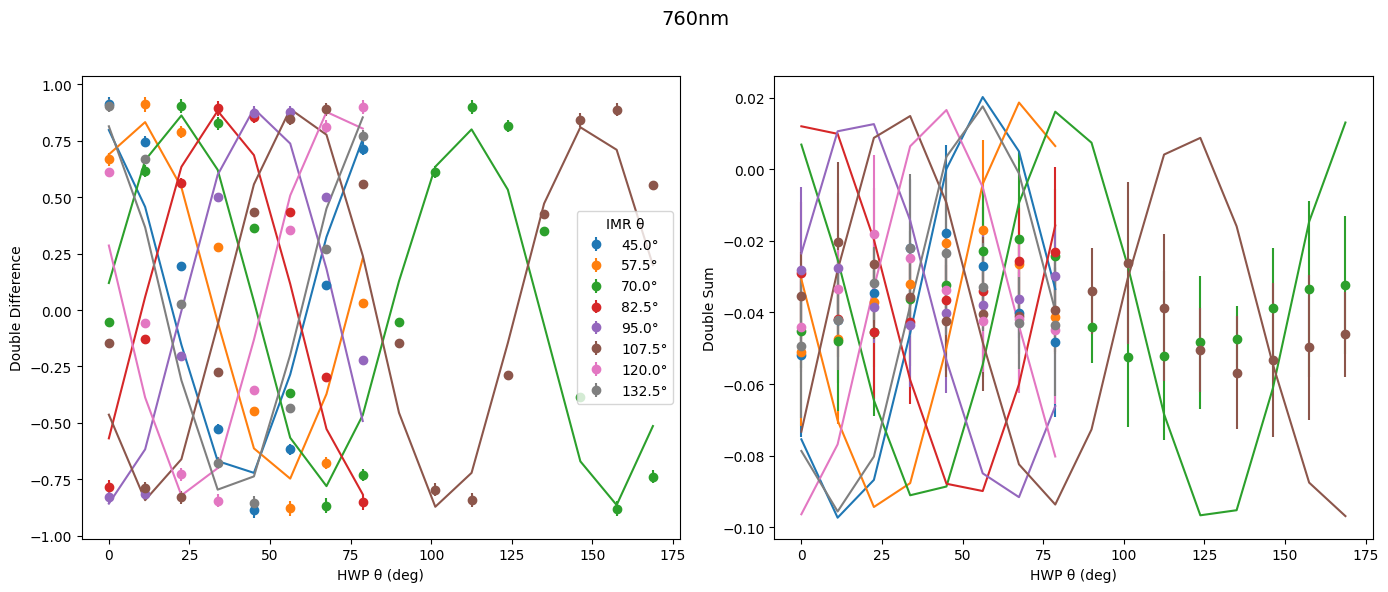

In [13]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 2.5949900310369003, 'epsilon': 0.002701419239880924, 'theta': 4.902148278343569}, 'flc': {'phi': 3.088663277960835, 'delta_theta': 4.553865046018213}, 'optics': {'phi': 0.991894933082528, 'epsilon': 0.06948734199917828, 'theta': -71.96155229430394}, 'image_rotator': {'phi': 3.0775484615652395}, 'hwp': {'phi': 3.0485391939996003, 'delta_theta': 2.52049523134324}, 'lp': {'theta': 4.980897146114103}}
Iteration #: 1
logl_value: 27.093881136109015
Best Fit Parameters: [ 3.15392092e+00  2.13345210e-06  1.05321610e+01  3.15000788e+00
  4.87755459e+00  1.38064844e+00  1.66181423e-01 -8.99868663e+01
  3.14739488e+00  3.12017636e+00  2.88661178e+00  4.60523290e+00]


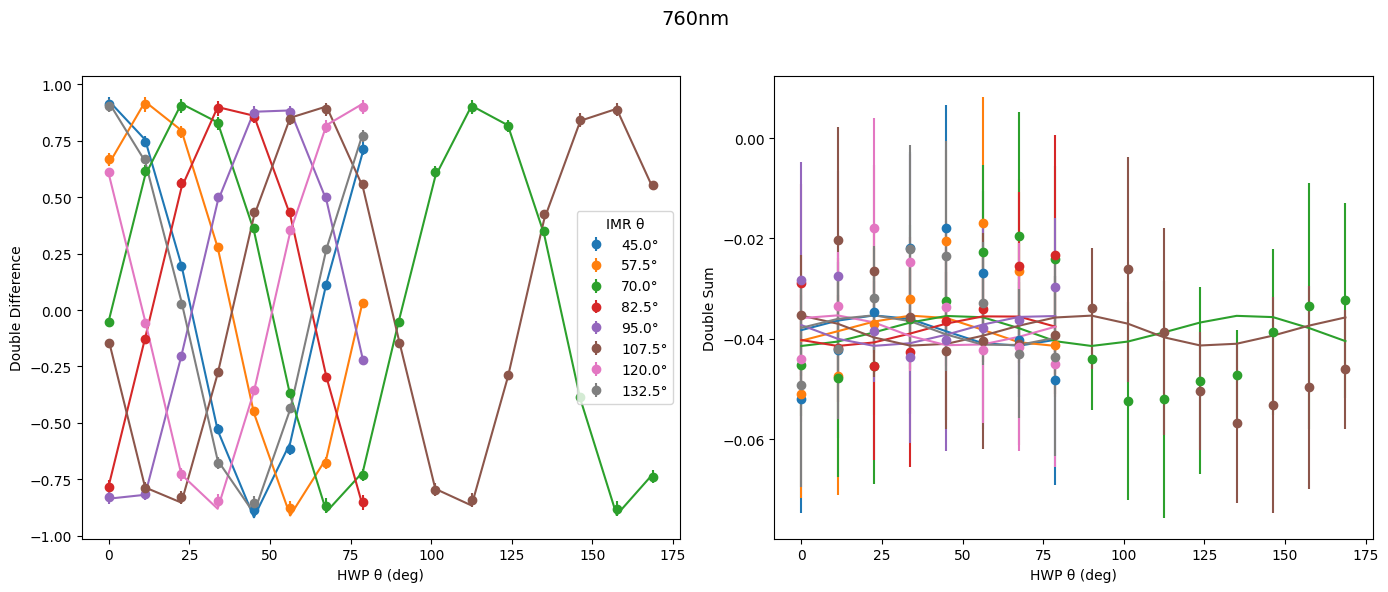

After p0: {'dichroic': {'phi': 3.153920917800697, 'epsilon': 2.1334521029493614e-06, 'theta': 10.532161047917135}, 'flc': {'phi': 3.150007878529756, 'delta_theta': 4.87755458541557}, 'optics': {'phi': 1.3806484441649722, 'epsilon': 0.1661814234981478, 'theta': -89.98686632847642}, 'image_rotator': {'phi': 3.147394875486313}, 'hwp': {'phi': 3.120176362756542, 'delta_theta': 2.886611777292936}, 'lp': {'theta': 4.605232903553135}}
Before p0: {'dichroic': {'phi': 3.153920917800697, 'epsilon': 2.1334521029493614e-06, 'theta': 10.532161047917135}, 'flc': {'phi': 3.150007878529756, 'delta_theta': 4.87755458541557}, 'optics': {'phi': 1.3806484441649722, 'epsilon': 0.1661814234981478, 'theta': -89.98686632847642}, 'image_rotator': {'phi': 3.147394875486313}, 'hwp': {'phi': 3.120176362756542, 'delta_theta': 2.886611777292936}, 'lp': {'theta': 4.605232903553135}}
Iteration #: 2
logl_value: 25.61149059375299
Best Fit Parameters: [ 3.17682985e+00  3.68553264e-04  1.11373129e+00  3.13774611e+00
  2.

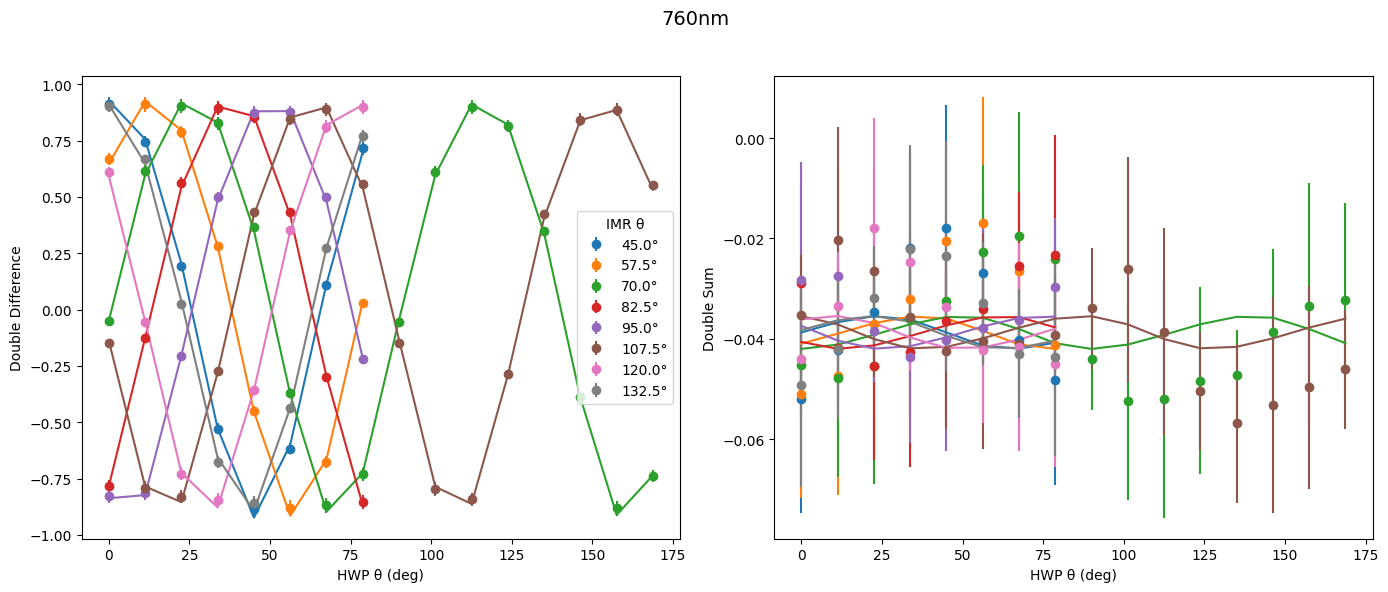

After p0: {'dichroic': {'phi': 3.176829849196757, 'epsilon': 0.0003685532635949473, 'theta': 1.1137312914276452}, 'flc': {'phi': 3.1377461069163566, 'delta_theta': 2.4758001615153553}, 'optics': {'phi': 1.454753309643543, 'epsilon': 0.1676054214800895, 'theta': -75.94513128888326}, 'image_rotator': {'phi': 3.163787794494368}, 'hwp': {'phi': 3.1226535522133894, 'delta_theta': -4.988992824452971}, 'lp': {'theta': 4.088501490973229}}
Before p0: {'dichroic': {'phi': 3.176829849196757, 'epsilon': 0.0003685532635949473, 'theta': 1.1137312914276452}, 'flc': {'phi': 3.1377461069163566, 'delta_theta': 2.4758001615153553}, 'optics': {'phi': 1.454753309643543, 'epsilon': 0.1676054214800895, 'theta': -75.94513128888326}, 'image_rotator': {'phi': 3.163787794494368}, 'hwp': {'phi': 3.1226535522133894, 'delta_theta': -4.988992824452971}, 'lp': {'theta': 4.088501490973229}}
Iteration #: 3
logl_value: 25.26159050331124
Best Fit Parameters: [ 3.38751704e+00  2.52503821e-04  6.75034568e-01  3.14644714e+0

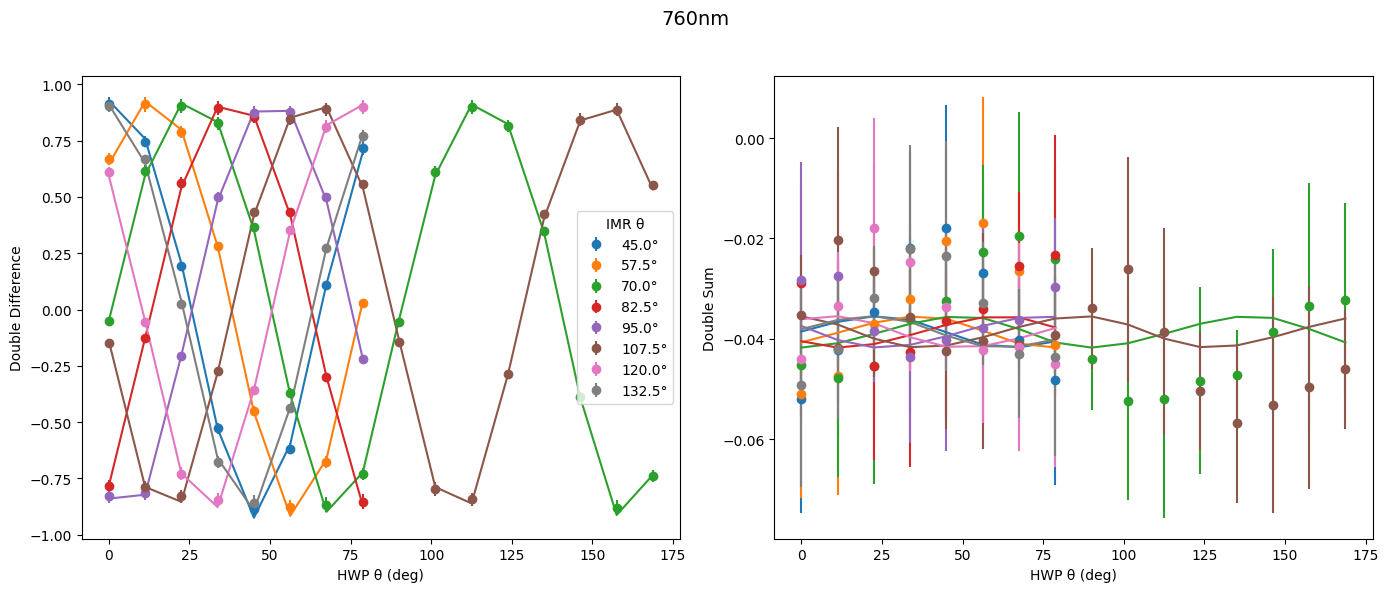

After p0: {'dichroic': {'phi': 3.3875170375021275, 'epsilon': 0.0002525038212225605, 'theta': 0.6750345680506666}, 'flc': {'phi': 3.1464471443194615, 'delta_theta': 2.7774119845051324}, 'optics': {'phi': 1.4048907937483484, 'epsilon': 0.16765596064792265, 'theta': -74.34845373367713}, 'image_rotator': {'phi': 3.164524206909663}, 'hwp': {'phi': 3.123112850873989, 'delta_theta': -4.968665293935164}, 'lp': {'theta': 4.998789100996815}}
Before p0: {'dichroic': {'phi': 3.3875170375021275, 'epsilon': 0.0002525038212225605, 'theta': 0.6750345680506666}, 'flc': {'phi': 3.1464471443194615, 'delta_theta': 2.7774119845051324}, 'optics': {'phi': 1.4048907937483484, 'epsilon': 0.16765596064792265, 'theta': -74.34845373367713}, 'image_rotator': {'phi': 3.164524206909663}, 'hwp': {'phi': 3.123112850873989, 'delta_theta': -4.968665293935164}, 'lp': {'theta': 4.998789100996815}}
Iteration #: 4
logl_value: 25.187131181295612
Best Fit Parameters: [ 3.34739905e+00  6.59443213e-06  6.95288224e-01  3.145069

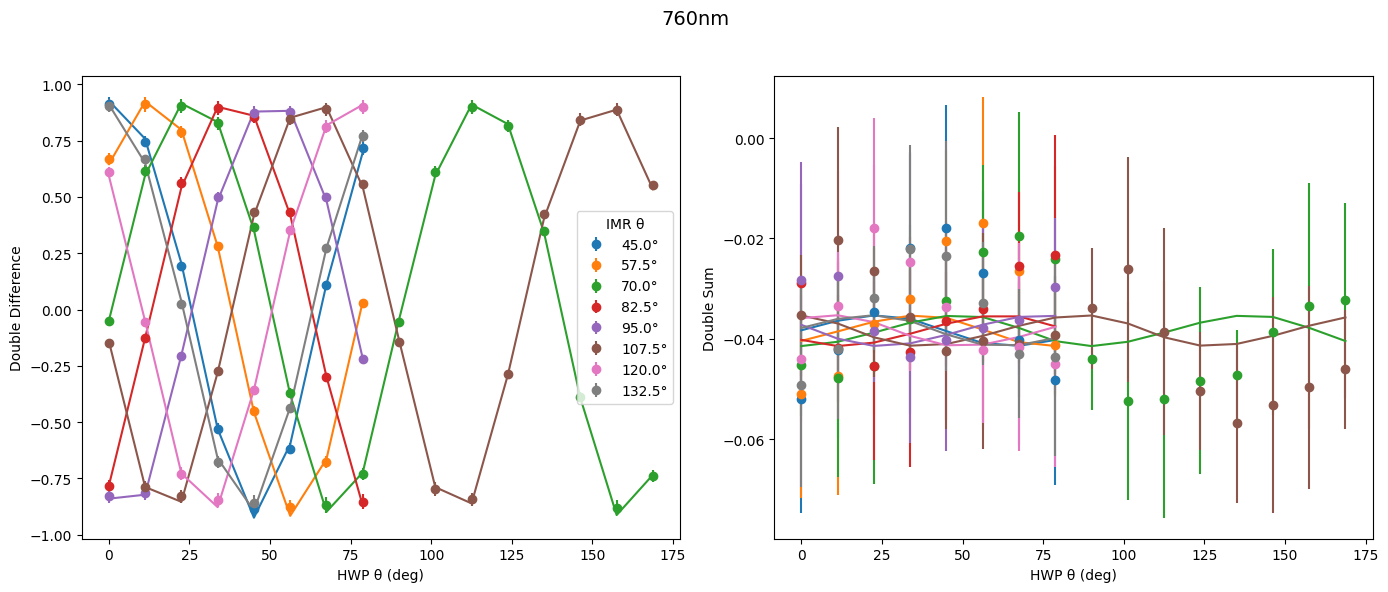

After p0: {'dichroic': {'phi': 3.3473990474460082, 'epsilon': 6.594432133473114e-06, 'theta': 0.6952882241944651}, 'flc': {'phi': 3.1450694150440217, 'delta_theta': 2.8643838369015864}, 'optics': {'phi': 1.3964083114272654, 'epsilon': 0.16768959375286768, 'theta': -74.20035553731728}, 'image_rotator': {'phi': 3.164331964761013}, 'hwp': {'phi': 3.123035078189713, 'delta_theta': -4.999995777655542}, 'lp': {'theta': 4.99999654375107}}
Before p0: {'dichroic': {'phi': 3.3473990474460082, 'epsilon': 6.594432133473114e-06, 'theta': 0.6952882241944651}, 'flc': {'phi': 3.1450694150440217, 'delta_theta': 2.8643838369015864}, 'optics': {'phi': 1.3964083114272654, 'epsilon': 0.16768959375286768, 'theta': -74.20035553731728}, 'image_rotator': {'phi': 3.164331964761013}, 'hwp': {'phi': 3.123035078189713, 'delta_theta': -4.999995777655542}, 'lp': {'theta': 4.99999654375107}}
Iteration #: 5
logl_value: 25.18560310115124
Best Fit Parameters: [ 3.35409108e+00  5.42961100e-11  6.89930418e-01  3.14529786e

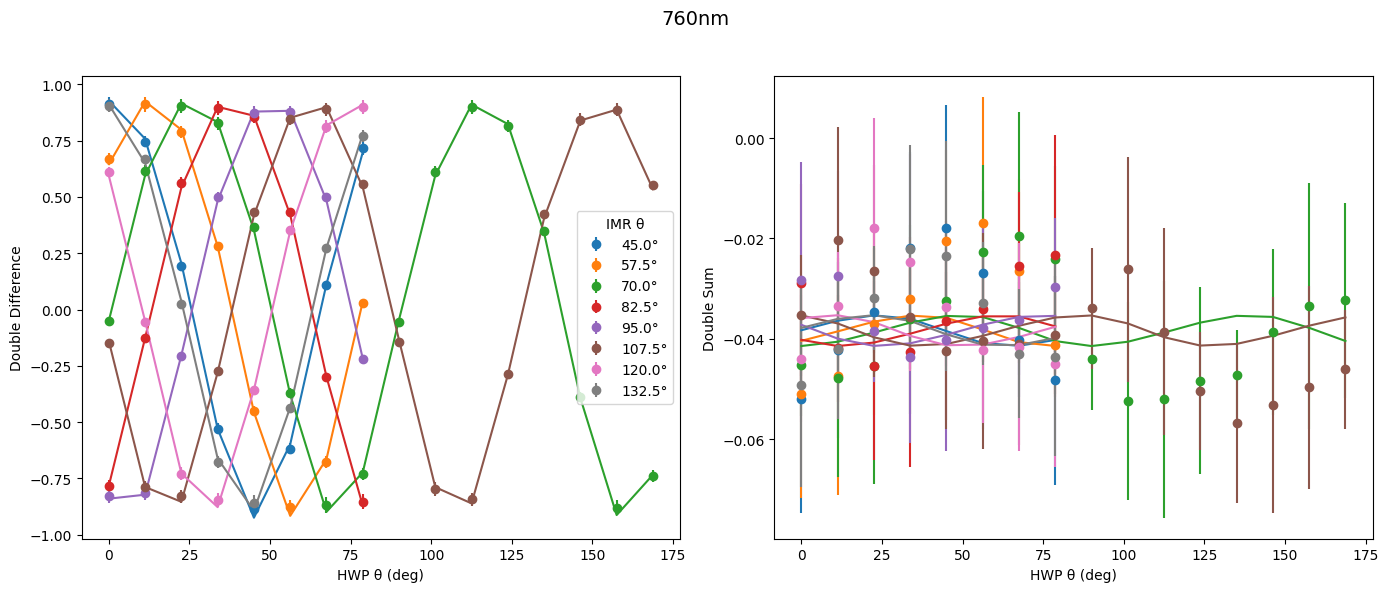

After p0: {'dichroic': {'phi': 3.354091075664753, 'epsilon': 5.429611003849887e-11, 'theta': 0.6899304180608674}, 'flc': {'phi': 3.145297861092357, 'delta_theta': 2.862647995759195}, 'optics': {'phi': 1.3959664482962297, 'epsilon': 0.16767268247632397, 'theta': -74.19147623464227}, 'image_rotator': {'phi': 3.164301944509205}, 'hwp': {'phi': 3.123067854503418, 'delta_theta': -4.999992535636528}, 'lp': {'theta': 4.999999810121627}}
Before p0: {'dichroic': {'phi': 3.354091075664753, 'epsilon': 5.429611003849887e-11, 'theta': 0.6899304180608674}, 'flc': {'phi': 3.145297861092357, 'delta_theta': 2.862647995759195}, 'optics': {'phi': 1.3959664482962297, 'epsilon': 0.16767268247632397, 'theta': -74.19147623464227}, 'image_rotator': {'phi': 3.164301944509205}, 'hwp': {'phi': 3.123067854503418, 'delta_theta': -4.999992535636528}, 'lp': {'theta': 4.999999810121627}}
Iteration #: 6
logl_value: 25.185601577573216
Best Fit Parameters: [ 3.35413110e+00  5.41422847e-11  6.89955120e-01  3.14530039e+00

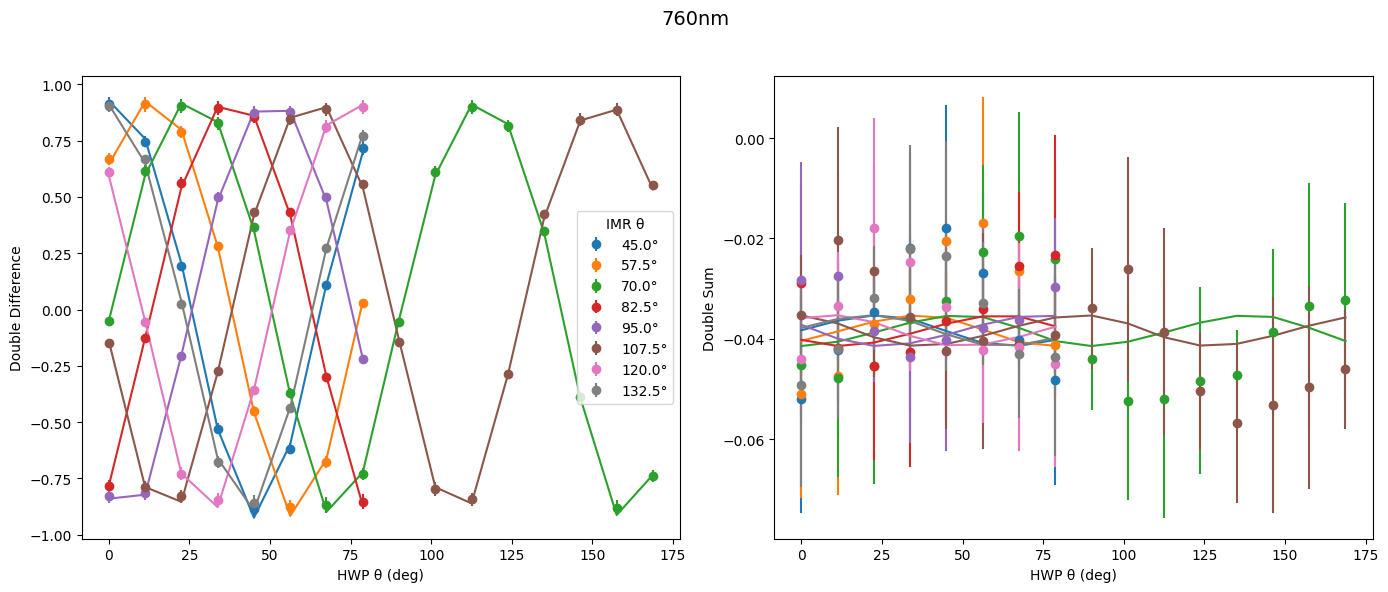

After p0: {'dichroic': {'phi': 3.354131101700471, 'epsilon': 5.4142284654874e-11, 'theta': 0.6899551204323957}, 'flc': {'phi': 3.14530039409655, 'delta_theta': 2.862673409109706}, 'optics': {'phi': 1.3959680825225518, 'epsilon': 0.1676728971035161, 'theta': -74.19143602206404}, 'image_rotator': {'phi': 3.1643010113151915}, 'hwp': {'phi': 3.1230670721152247, 'delta_theta': -4.999999995573386}, 'lp': {'theta': 4.999999866305197}}
Before p0: {'dichroic': {'phi': 3.354131101700471, 'epsilon': 5.4142284654874e-11, 'theta': 0.6899551204323957}, 'flc': {'phi': 3.14530039409655, 'delta_theta': 2.862673409109706}, 'optics': {'phi': 1.3959680825225518, 'epsilon': 0.1676728971035161, 'theta': -74.19143602206404}, 'image_rotator': {'phi': 3.1643010113151915}, 'hwp': {'phi': 3.1230670721152247, 'delta_theta': -4.999999995573386}, 'lp': {'theta': 4.999999866305197}}
Iteration #: 7
logl_value: 25.18560156443519
Best Fit Parameters: [ 3.35422332e+00  5.50439438e-11  6.89977128e-01  3.14530441e+00
  2.

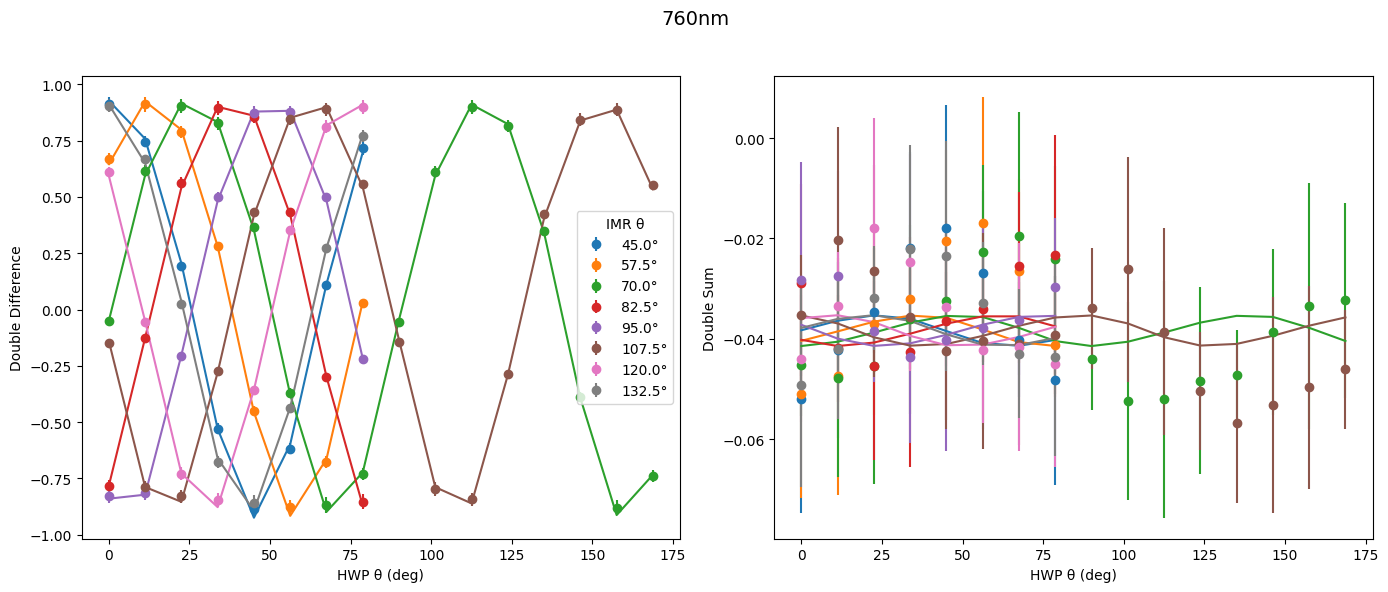

After p0: {'dichroic': {'phi': 3.3542233228214453, 'epsilon': 5.504394378172385e-11, 'theta': 0.6899771283793721}, 'flc': {'phi': 3.1453044126213845, 'delta_theta': 2.862688962439414}, 'optics': {'phi': 1.3959738204206809, 'epsilon': 0.16767271491325814, 'theta': -74.19144491389007}, 'image_rotator': {'phi': 3.1643014754566856}, 'hwp': {'phi': 3.1230675682336484, 'delta_theta': -4.999999997047759}, 'lp': {'theta': 4.999999805169348}}
Before p0: {'dichroic': {'phi': 3.3542233228214453, 'epsilon': 5.504394378172385e-11, 'theta': 0.6899771283793721}, 'flc': {'phi': 3.1453044126213845, 'delta_theta': 2.862688962439414}, 'optics': {'phi': 1.3959738204206809, 'epsilon': 0.16767271491325814, 'theta': -74.19144491389007}, 'image_rotator': {'phi': 3.1643014754566856}, 'hwp': {'phi': 3.1230675682336484, 'delta_theta': -4.999999997047759}, 'lp': {'theta': 4.999999805169348}}
Iteration #: 8
logl_value: 25.185601498131366
Best Fit Parameters: [ 3.35440126e+00  5.46420807e-11  6.90177528e-01  3.1453

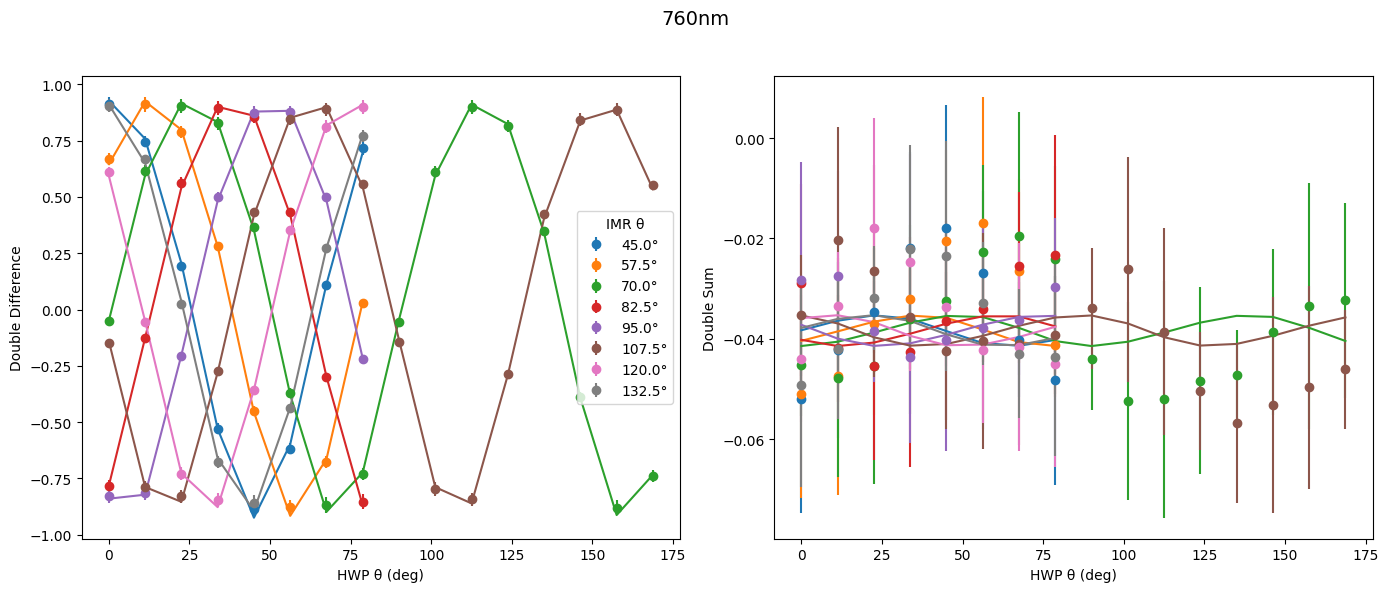

After p0: {'dichroic': {'phi': 3.354401255677584, 'epsilon': 5.4642080650958084e-11, 'theta': 0.6901775283670759}, 'flc': {'phi': 3.1453152028434284, 'delta_theta': 2.8628032670384327}, 'optics': {'phi': 1.3959992622142132, 'epsilon': 0.16767279454124892, 'theta': -74.19159345882099}, 'image_rotator': {'phi': 3.164301278351851}, 'hwp': {'phi': 3.1230679313327614, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999999872333}}
Before p0: {'dichroic': {'phi': 3.354401255677584, 'epsilon': 5.4642080650958084e-11, 'theta': 0.6901775283670759}, 'flc': {'phi': 3.1453152028434284, 'delta_theta': 2.8628032670384327}, 'optics': {'phi': 1.3959992622142132, 'epsilon': 0.16767279454124892, 'theta': -74.19159345882099}, 'image_rotator': {'phi': 3.164301278351851}, 'hwp': {'phi': 3.1230679313327614, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999999872333}}
Iteration #: 9
logl_value: 25.185601497793062
Best Fit Parameters: [ 3.35443314e+00  5.55506778e-11  6.90240853e-01  3.14531785e+00
  2.86285722e+00  1

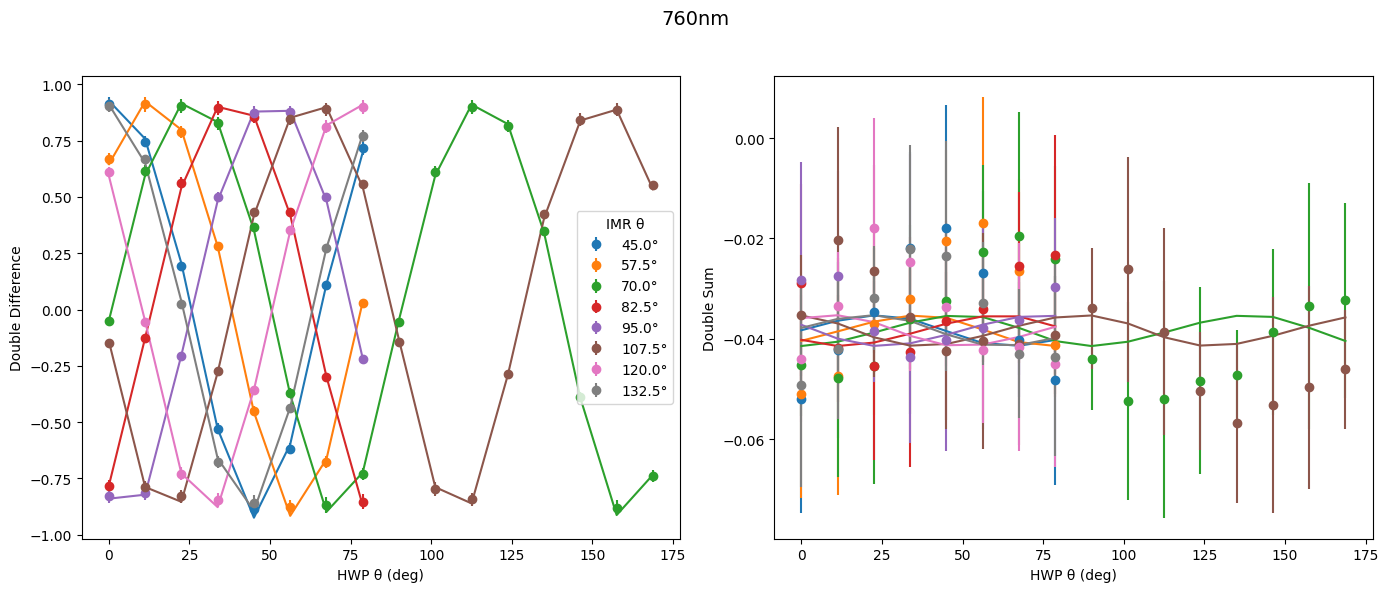

After p0: {'dichroic': {'phi': 3.3544331434743793, 'epsilon': 5.55506777756701e-11, 'theta': 0.6902408533748361}, 'flc': {'phi': 3.1453178474748094, 'delta_theta': 2.8628572157453585}, 'optics': {'phi': 1.3960032180617434, 'epsilon': 0.16767301680514735, 'theta': -74.19160728511721}, 'image_rotator': {'phi': 3.1643012471434435}, 'hwp': {'phi': 3.123068348434253, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999844152073}}
Before p0: {'dichroic': {'phi': 3.3544331434743793, 'epsilon': 5.55506777756701e-11, 'theta': 0.6902408533748361}, 'flc': {'phi': 3.1453178474748094, 'delta_theta': 2.8628572157453585}, 'optics': {'phi': 1.3960032180617434, 'epsilon': 0.16767301680514735, 'theta': -74.19160728511721}, 'image_rotator': {'phi': 3.1643012471434435}, 'hwp': {'phi': 3.123068348434253, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999844152073}}
Iteration #: 10
logl_value: 25.185601452734595
Best Fit Parameters: [ 3.35449485e+00  5.29403102e-11  6.90395623e-01  3.14532238e+00
  2.86298207e+00  1.

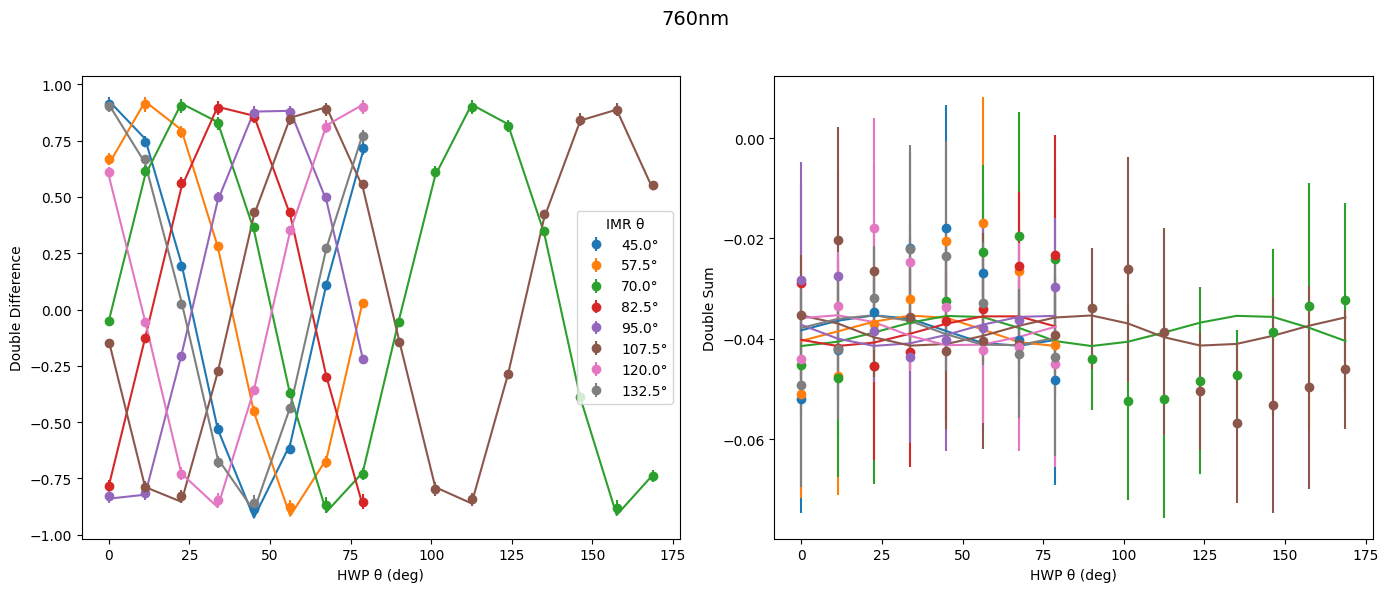

After p0: {'dichroic': {'phi': 3.3544948485237454, 'epsilon': 5.294031021260409e-11, 'theta': 0.6903956231977432}, 'flc': {'phi': 3.145322382409324, 'delta_theta': 2.862982072421511}, 'optics': {'phi': 1.3960105649654597, 'epsilon': 0.1676729351328702, 'theta': -74.19162087993098}, 'image_rotator': {'phi': 3.164301232017949}, 'hwp': {'phi': 3.1230675819559646, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999963768811}}
Before p0: {'dichroic': {'phi': 3.3544948485237454, 'epsilon': 5.294031021260409e-11, 'theta': 0.6903956231977432}, 'flc': {'phi': 3.145322382409324, 'delta_theta': 2.862982072421511}, 'optics': {'phi': 1.3960105649654597, 'epsilon': 0.1676729351328702, 'theta': -74.19162087993098}, 'image_rotator': {'phi': 3.164301232017949}, 'hwp': {'phi': 3.1230675819559646, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999963768811}}
Iteration #: 11
logl_value: 25.185601419182667
Best Fit Parameters: [ 3.35433113e+00  5.17630100e-11  6.90424658e-01  3.14531528e+00
  2.86306503e+00  1.3959

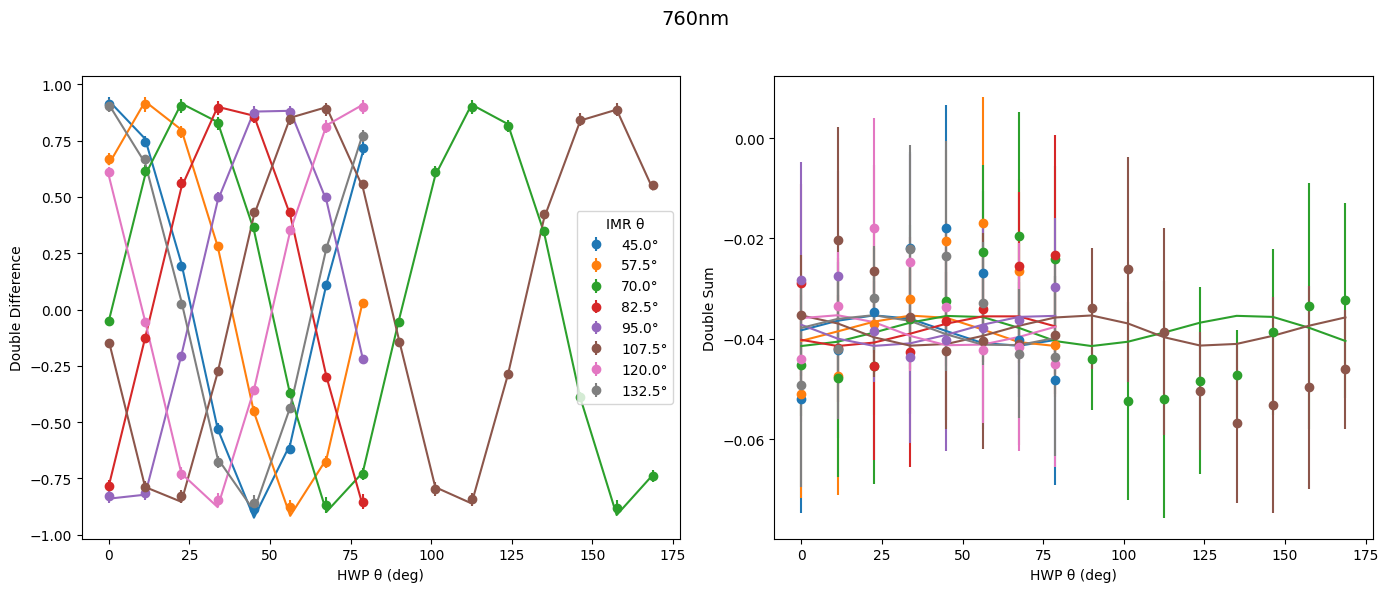

After p0: {'dichroic': {'phi': 3.354331133979425, 'epsilon': 5.17630100382872e-11, 'theta': 0.6904246580068122}, 'flc': {'phi': 3.1453152817753054, 'delta_theta': 2.8630650279397676}, 'optics': {'phi': 1.3959953407181724, 'epsilon': 0.16767290732394494, 'theta': -74.19156008869032}, 'image_rotator': {'phi': 3.164302748226169}, 'hwp': {'phi': 3.1230674709347492, 'delta_theta': -5.0}, 'lp': {'theta': 4.99999999038601}}
Before p0: {'dichroic': {'phi': 3.354331133979425, 'epsilon': 5.17630100382872e-11, 'theta': 0.6904246580068122}, 'flc': {'phi': 3.1453152817753054, 'delta_theta': 2.8630650279397676}, 'optics': {'phi': 1.3959953407181724, 'epsilon': 0.16767290732394494, 'theta': -74.19156008869032}, 'image_rotator': {'phi': 3.164302748226169}, 'hwp': {'phi': 3.1230674709347492, 'delta_theta': -5.0}, 'lp': {'theta': 4.99999999038601}}
Iteration #: 12
logl_value: 25.18560141275724
Best Fit Parameters: [ 3.35437773e+00  5.26243650e-11  6.90469012e-01  3.14531786e+00
  2.86309362e+00  1.39600

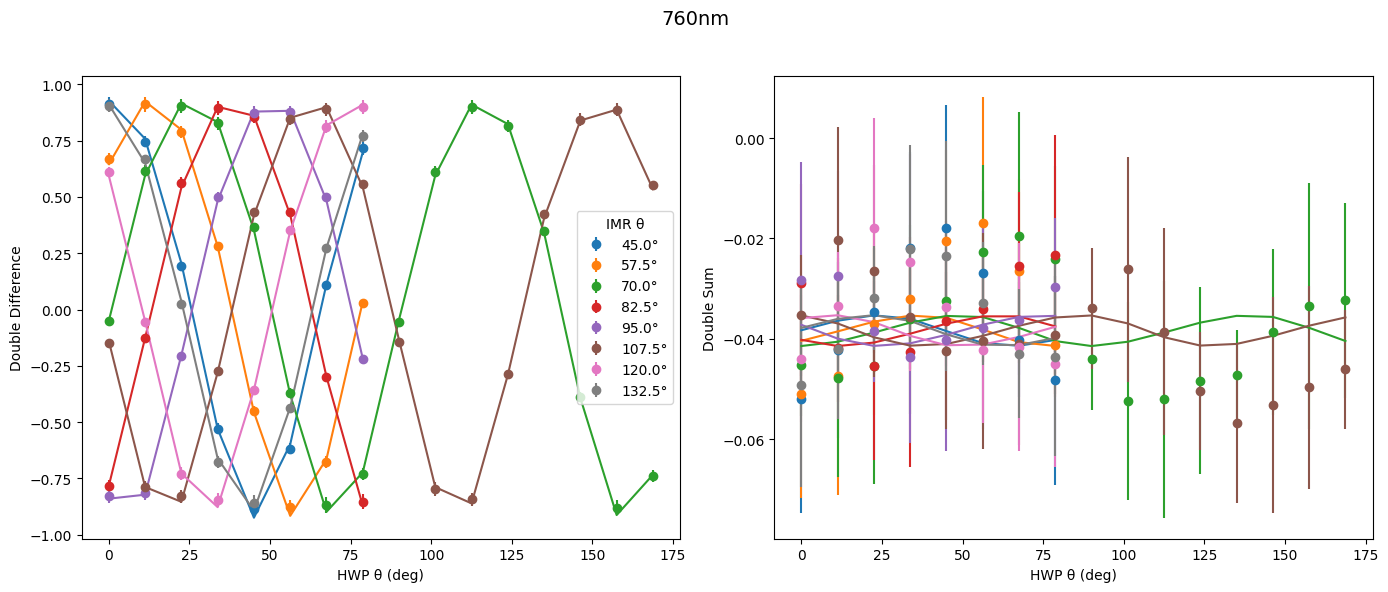

After p0: {'dichroic': {'phi': 3.3543777274192217, 'epsilon': 5.262436502869085e-11, 'theta': 0.6904690123437472}, 'flc': {'phi': 3.145317860217291, 'delta_theta': 2.863093624920529}, 'optics': {'phi': 1.396001167865144, 'epsilon': 0.16767284278101113, 'theta': -74.19157833678926}, 'image_rotator': {'phi': 3.1643014962067237}, 'hwp': {'phi': 3.123067777882116, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999916106544}}
Before p0: {'dichroic': {'phi': 3.3543777274192217, 'epsilon': 5.262436502869085e-11, 'theta': 0.6904690123437472}, 'flc': {'phi': 3.145317860217291, 'delta_theta': 2.863093624920529}, 'optics': {'phi': 1.396001167865144, 'epsilon': 0.16767284278101113, 'theta': -74.19157833678926}, 'image_rotator': {'phi': 3.1643014962067237}, 'hwp': {'phi': 3.123067777882116, 'delta_theta': -5.0}, 'lp': {'theta': 4.999999916106544}}
Iteration #: 13
logl_value: 25.18560141275724
Best Fit Parameters: [ 3.35437773e+00  5.26243650e-11  6.90469012e-01  3.14531786e+00
  2.86309362e+00  1.39600

In [14]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-np.pi, np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (-2 * np.pi, 2 * np.pi),
    },
    "hwp": {
        "phi": (
             (-2 * np.pi, 2 * np.pi)
        ),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_no_retardance_constraints_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

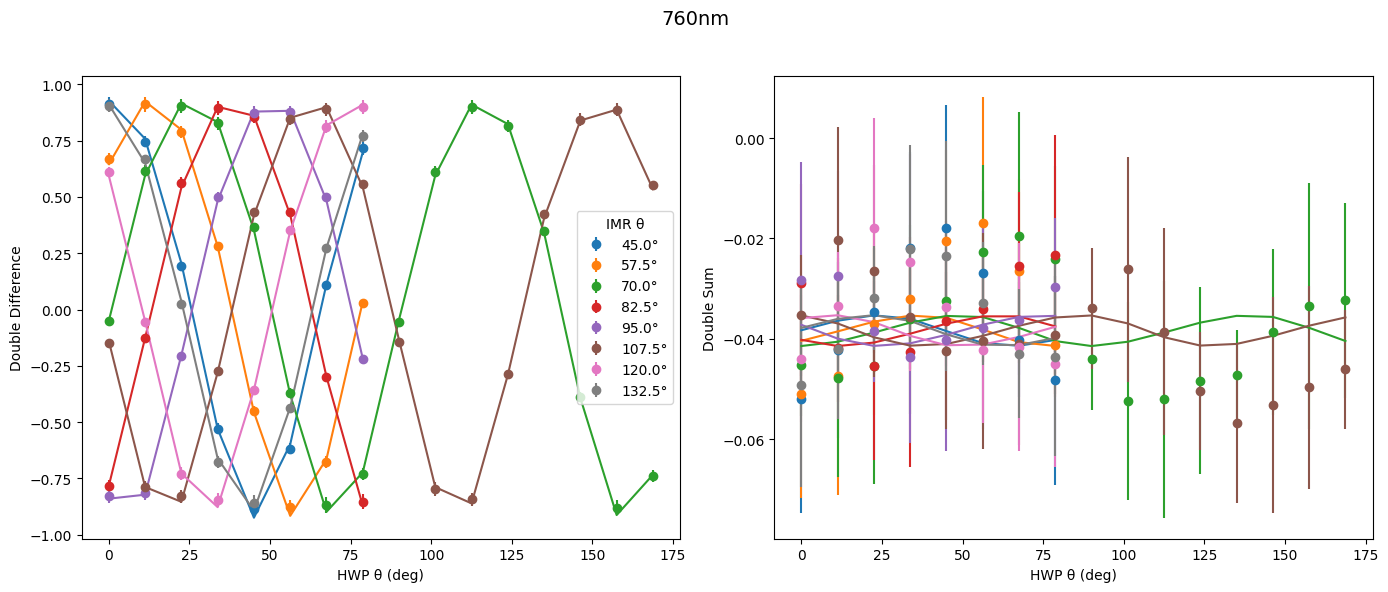

In [15]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)